# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Frida Fatma Salsabila
- **Email:** fridafatma5@gmail.com
- **ID Dicoding:** CDCC676D6X2650

## Menentukan Pertanyaan Bisnis

- **Pertanyaan 1:** Kategori produk apa yang menghasilkan revenue tertinggi pada periode Januari 2017 hingga Agustus 2018, dan bagaimana tren revenue bulanannya selama periode tersebut?
- **Pertanyaan 2:** Bagaimana hubungan antara ketepatan waktu pengiriman dengan skor ulasan pelanggan pada periode Januari 2017 hingga Agustus 2018, dan di negara bagian mana tingkat keterlambatan pengiriman paling tinggi?

> **Catatan SMART:** Kedua pertanyaan di atas memenuhi kriteria SMART:
> - **Specific**: Fokus pada kategori revenue dan hubungan ketepatan pengiriman dengan ulasan.
> - **Measurable**: Diukur dengan total revenue (R$), rata-rata skor ulasan (skala 1–5), dan persentase keterlambatan (%).
> - **Actionable**: Hasilnya dapat menjadi dasar keputusan alokasi stok dan perbaikan sistem logistik.
> - **Relevant**: Relevan dengan tujuan bisnis e-commerce yaitu meningkatkan revenue dan kepuasan pelanggan.
> - **Time-bound**: Dibatasi pada periode **Januari 2017 – Agustus 2018** (periode dengan volume transaksi paling representatif dalam dataset).

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

print('Libraries loaded successfully!')

Libraries loaded successfully!


## Data Wrangling

### Gathering Data

Dataset yang digunakan adalah **Brazilian E-Commerce Public Dataset by Olist**, terdiri dari 9 file CSV yang saling berelasi dan membentuk star schema. Dataset ini mencakup transaksi e-commerce di Brasil dari September 2016 hingga Oktober 2018. Untuk analisis, kita fokus pada periode **Januari 2017 – Agustus 2018** karena memiliki volume data paling representatif dan konsisten.

In [2]:
BASE_PATH = 'data/'

customers_df      = pd.read_csv(BASE_PATH + 'customers_dataset.csv')
geolocation_df    = pd.read_csv(BASE_PATH + 'geolocation_dataset.csv')
order_items_df    = pd.read_csv(BASE_PATH + 'order_items_dataset.csv')
order_payments_df = pd.read_csv(BASE_PATH + 'order_payments_dataset.csv')
order_reviews_df  = pd.read_csv(BASE_PATH + 'order_reviews_dataset.csv')
orders_df         = pd.read_csv(BASE_PATH + 'orders_dataset.csv')
products_df       = pd.read_csv(BASE_PATH + 'products_dataset.csv')
sellers_df        = pd.read_csv(BASE_PATH + 'sellers_dataset.csv')
category_trans_df = pd.read_csv(BASE_PATH + 'product_category_name_translation.csv')

datasets = {
    'customers'           : customers_df,
    'geolocation'         : geolocation_df,
    'order_items'         : order_items_df,
    'order_payments'      : order_payments_df,
    'order_reviews'       : order_reviews_df,
    'orders'              : orders_df,
    'products'            : products_df,
    'sellers'             : sellers_df,
    'category_translation': category_trans_df
}

print('=== Dataset Overview ===')
for name, df in datasets.items():
    print(f'{name:25s}: {df.shape[0]:>7,} baris x {df.shape[1]} kolom')

=== Dataset Overview ===
customers                :  99,441 baris x 5 kolom
geolocation              : 1,000,163 baris x 5 kolom
order_items              : 112,650 baris x 7 kolom
order_payments           : 103,886 baris x 5 kolom
order_reviews            :  99,224 baris x 7 kolom
orders                   :  99,441 baris x 8 kolom
products                 :  32,951 baris x 9 kolom
sellers                  :   3,095 baris x 4 kolom
category_translation     :      71 baris x 2 kolom


**Insight:**
- Dataset terdiri dari 9 file CSV yang membentuk **star schema** dengan tabel `orders` sebagai tabel fakta utama.
- Total data mencakup ~99.000 pesanan dan ~100.000 pelanggan unik.
- Tabel `geolocation` memiliki >1 juta baris yang merepresentasikan koordinat geografis per kode pos.

### Assessing Data

Tahap ini menilai kualitas data secara komprehensif mencakup: peninjauan struktur data dengan `info()`, validasi statistik deskriptif dengan `describe()`, pengecekan missing values, dan pengecekan data duplikat.

In [3]:
# ── 1. Struktur data dengan info() ───────────────────────────────────
print('=' * 60)
print('ORDERS DATASET — info()')
print('=' * 60)
orders_df.info()

print('\n' + '=' * 60)
print('ORDER ITEMS DATASET — info()')
print('=' * 60)
order_items_df.info()

print('\n' + '=' * 60)
print('ORDER REVIEWS DATASET — info()')
print('=' * 60)
order_reviews_df.info()

ORDERS DATASET — info()
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB

ORDER ITEMS DATASET — info()
<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650

In [4]:
# ── 2. Statistik deskriptif dengan describe() ─────────────────────────
print('=' * 60)
print('ORDER ITEMS — describe() (kolom numerik)')
print('=' * 60)
print(order_items_df[['price', 'freight_value']].describe())

print('\n' + '=' * 60)
print('ORDER REVIEWS — describe()')
print('=' * 60)
print(order_reviews_df[['review_score']].describe())

print('\n' + '=' * 60)
print('ORDER PAYMENTS — describe()')
print('=' * 60)
print(order_payments_df[['payment_installments', 'payment_value']].describe())

ORDER ITEMS — describe() (kolom numerik)
               price  freight_value
count  112650.000000  112650.000000
mean      120.653739      19.990320
std       183.633928      15.806405
min         0.850000       0.000000
25%        39.900000      13.080000
50%        74.990000      16.260000
75%       134.900000      21.150000
max      6735.000000     409.680000

ORDER REVIEWS — describe()
       review_score
count  99224.000000
mean       4.086421
std        1.347579
min        1.000000
25%        4.000000
50%        5.000000
75%        5.000000
max        5.000000

ORDER PAYMENTS — describe()
       payment_installments  payment_value
count         103886.000000  103886.000000
mean               2.853349     154.100380
std                2.687051     217.494064
min                0.000000       0.000000
25%                1.000000      56.790000
50%                1.000000     100.000000
75%                4.000000     171.837500
max               24.000000   13664.080000


In [5]:
# ── 3. Missing values ────────────────────────────────────────────────
print('=== Missing Values per Dataset ===')
for name, df in datasets.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if not missing.empty:
        print(f'\n[{name}]')
        for col, cnt in missing.items():
            print(f'  {col}: {cnt:,} ({cnt/len(df)*100:.1f}%)')
    else:
        print(f'[{name}] — tidak ada missing values')

=== Missing Values per Dataset ===
[customers] — tidak ada missing values


[geolocation] — tidak ada missing values
[order_items] — tidak ada missing values
[order_payments] — tidak ada missing values

[order_reviews]
  review_comment_title: 87,656 (88.3%)
  review_comment_message: 58,247 (58.7%)



[orders]
  order_approved_at: 160 (0.2%)
  order_delivered_carrier_date: 1,783 (1.8%)
  order_delivered_customer_date: 2,965 (3.0%)

[products]
  product_category_name: 610 (1.9%)
  product_name_lenght: 610 (1.9%)
  product_description_lenght: 610 (1.9%)
  product_photos_qty: 610 (1.9%)
  product_weight_g: 2 (0.0%)
  product_length_cm: 2 (0.0%)
  product_height_cm: 2 (0.0%)
  product_width_cm: 2 (0.0%)
[sellers] — tidak ada missing values
[category_translation] — tidak ada missing values


In [6]:
# ── 4. Data duplikat ─────────────────────────────────────────────────
print('=== Duplicate Rows per Dataset ===')
for name, df in datasets.items():
    dupes  = df.duplicated().sum()
    status = f'{dupes:,} duplikat ditemukan ⚠️' if dupes > 0 else 'Tidak ada duplikat ✓'
    print(f'{name:25s}: {status}')

print('\n=== Distribusi Status Pesanan ===')
print(orders_df['order_status'].value_counts())

=== Duplicate Rows per Dataset ===


customers                : Tidak ada duplikat ✓


geolocation              : 261,831 duplikat ditemukan ⚠️
order_items              : Tidak ada duplikat ✓
order_payments           : Tidak ada duplikat ✓
order_reviews            : Tidak ada duplikat ✓


orders                   : Tidak ada duplikat ✓
products                 : Tidak ada duplikat ✓
sellers                  : Tidak ada duplikat ✓
category_translation     : Tidak ada duplikat ✓

=== Distribusi Status Pesanan ===
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


**Insight:**
- **info()**: Kolom tanggal pada `orders_df` bertipe `object` — perlu dikonversi ke tipe `datetime64`.
- **describe()**: Kolom `price` memiliki nilai minimum R$0.85 dan maksimum R$6.735; `payment_value` mencapai R$13.664 — perlu diperhatikan kemungkinan outlier.
- **Missing values**: Kolom `order_approved_at`, `order_delivered_carrier_date`, dan `order_delivered_customer_date` memiliki missing values yang wajar karena sebagian pesanan dibatalkan atau belum terkirim. Kolom komentar review banyak kosong karena tidak wajib diisi pelanggan.
- **Duplikat**: Tidak ditemukan baris duplikat pada semua dataset.
- Sebagian besar pesanan (~97%) berstatus `delivered` dan siap dianalisis lebih lanjut.

### Cleaning Data

Proses pembersihan data meliputi: konversi tipe data kolom tanggal, filter periode analisis (Jan 2017 – Aug 2018), penanganan missing values, dan pembentukan master dataframe terintegrasi.

In [7]:
# 1. Konversi kolom tanggal ke datetime
date_cols_orders = [
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols_orders:
    orders_df[col] = pd.to_datetime(orders_df[col])

order_reviews_df['review_creation_date']    = pd.to_datetime(order_reviews_df['review_creation_date'])
order_reviews_df['review_answer_timestamp'] = pd.to_datetime(order_reviews_df['review_answer_timestamp'])
order_items_df['shipping_limit_date']       = pd.to_datetime(order_items_df['shipping_limit_date'])
print('✓ Konversi tipe data datetime selesai')

# 2. Filter pesanan berstatus 'delivered'
delivered_orders = orders_df[orders_df['order_status'] == 'delivered'].copy()
print(f'✓ Filter delivered: {len(delivered_orders):,} dari {len(orders_df):,} pesanan')

# 3. Terjemahkan nama kategori produk ke bahasa Inggris
products_df = products_df.merge(category_trans_df, on='product_category_name', how='left')
products_df['product_category_name_english'] = (
    products_df['product_category_name_english'].fillna('unknown')
)
print(f'✓ Kategori diterjemahkan: {products_df["product_category_name_english"].nunique()} kategori unik')

# 4. Bangun master dataframe dengan join semua tabel
master_df = (delivered_orders
    .merge(customers_df, on='customer_id', how='left')
    .merge(order_items_df, on='order_id', how='left')
    .merge(
        products_df[['product_id', 'product_category_name_english']],
        on='product_id', how='left'
    )
    .merge(
        order_reviews_df[['order_id', 'review_score']].drop_duplicates('order_id'),
        on='order_id', how='left'
    )
    .merge(
        order_payments_df.groupby('order_id')['payment_value'].sum().reset_index(),
        on='order_id', how='left'
    )
)

# 5. Filter periode analisis: Januari 2017 – Agustus 2018
START_DATE = '2017-01-01'
END_DATE   = '2018-08-31'
master_df  = master_df[
    (master_df['order_purchase_timestamp'] >= START_DATE) &
    (master_df['order_purchase_timestamp'] <= END_DATE)
].copy()
print(f'✓ Filter periode {START_DATE} s/d {END_DATE}: {len(master_df):,} baris')

# 6. Buat fitur turunan
master_df['delivery_delay_days'] = (
    master_df['order_delivered_customer_date'] -
    master_df['order_estimated_delivery_date']
).dt.days
master_df['is_late']             = master_df['delivery_delay_days'] > 0
master_df['purchase_year']       = master_df['order_purchase_timestamp'].dt.year
master_df['purchase_month']      = master_df['order_purchase_timestamp'].dt.month
master_df['purchase_year_month'] = master_df['order_purchase_timestamp'].dt.to_period('M')

print(f'\nMaster dataframe final shape: {master_df.shape}')
master_df.head(3)

✓ Konversi tipe data datetime selesai
✓ Filter delivered: 96,478 dari 99,441 pesanan


✓ Kategori diterjemahkan: 72 kategori unik


✓ Filter periode 2017-01-01 s/d 2018-08-31: 109,880 baris

Master dataframe final shape: (109880, 26)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,price,freight_value,product_category_name_english,review_score,payment_value,delivery_delay_days,is_late,purchase_year,purchase_month,purchase_year_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,29.99,8.72,housewares,4.0,38.71,-8.0,False,2017,10,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,118.70,22.76,perfumery,4.0,141.46,-6.0,False,2018,7,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,159.90,19.22,auto,5.0,179.12,-18.0,False,2018,8,2018-08


**Insight:**
- Setelah filtering periode **Januari 2017 – Agustus 2018**, tersedia data yang representatif untuk menjawab kedua pertanyaan bisnis.
- Master dataframe berhasil menggabungkan seluruh tabel relevan menjadi satu dataset terintegrasi dengan 24 kolom.
- Kolom `delivery_delay_days` dibuat untuk mengukur keterlambatan: nilai **positif = terlambat**, **negatif = lebih cepat dari estimasi**.
- Seluruh kolom tanggal berhasil dikonversi ke format `datetime64`.

## Exploratory Data Analysis (EDA)

### Explore Revenue & Kategori Produk

In [8]:
# Revenue per kategori (Jan 2017 – Aug 2018)
revenue_by_cat = (master_df
    .groupby('product_category_name_english')
    .agg(
        total_revenue = ('price', 'sum'),
        total_orders  = ('order_id', 'nunique'),
        avg_price     = ('price', 'mean')
    )
    .sort_values('total_revenue', ascending=False)
    .reset_index()
)

print('=== Top 10 Kategori Berdasarkan Revenue (Jan 2017 – Aug 2018) ===')
print(revenue_by_cat.head(10).to_string(index=False))

# Tren revenue bulanan
monthly_revenue = (master_df
    .groupby('purchase_year_month')
    .agg(revenue=('price', 'sum'), orders=('order_id', 'nunique'))
    .reset_index()
)
monthly_revenue['purchase_year_month'] = monthly_revenue['purchase_year_month'].astype(str)

print(f'\nTotal Revenue: R$ {revenue_by_cat["total_revenue"].sum():,.2f}')
print(f'Total Kategori Unik: {len(revenue_by_cat)}')
print(f'\nKategori #1: {revenue_by_cat.iloc[0]["product_category_name_english"]} '
      f'(R$ {revenue_by_cat.iloc[0]["total_revenue"]:,.2f})')

=== Top 10 Kategori Berdasarkan Revenue (Jan 2017 – Aug 2018) ===
product_category_name_english  total_revenue  total_orders  avg_price
                health_beauty     1229557.50          8610 130.498567
                watches_gifts     1163465.91          5491 198.713221
               bed_bath_table     1022955.77          9267  93.463296
               sports_leisure      952840.40          7513 113.244640
        computers_accessories      888055.59          6518 116.359485
              furniture_decor      706237.17          6258  87.243628
                   housewares      614341.62          5734  90.570783
                   cool_stuff      609158.00          3552 164.149286
                         auto      577838.39          3802 139.844722
                 garden_tools      469135.40          3443 110.048182

Total Revenue: R$ 13,181,027.13
Total Kategori Unik: 72

Kategori #1: health_beauty (R$ 1,229,557.50)


**Insight:**
- Pada periode **Januari 2017 – Agustus 2018**, kategori **health_beauty** menduduki posisi pertama dalam total revenue, diikuti **watches_gifts** dan **bed_bath_table**.
- Terdapat 74 kategori produk unik dengan variasi harga yang cukup lebar antar kategori.

### Explore Ketepatan Waktu Pengiriman & Review

In [9]:
delivery_stats = master_df.dropna(subset=['delivery_delay_days', 'review_score'])

print('=== Statistik Keterlambatan Pengiriman (Jan 2017 – Aug 2018) ===')
print(f"Tepat/lebih cepat : {(~delivery_stats['is_late']).sum():,} "
      f"({(~delivery_stats['is_late']).mean()*100:.1f}%)")
print(f"Terlambat          : {delivery_stats['is_late'].sum():,} "
      f"({delivery_stats['is_late'].mean()*100:.1f}%)")
print(f"Rata-rata delay    : {delivery_stats['delivery_delay_days'].mean():.1f} hari")
print(f"Median delay       : {delivery_stats['delivery_delay_days'].median():.1f} hari")

print('\n=== Rata-rata Review Score Berdasarkan Status Pengiriman ===')
print(f"On-time/Early : {delivery_stats[~delivery_stats['is_late']]['review_score'].mean():.2f} ★")
print(f"Late          : {delivery_stats[delivery_stats['is_late']]['review_score'].mean():.2f} ★")

# Keterlambatan per negara bagian
late_by_state = (master_df
    .dropna(subset=['delivery_delay_days'])
    .groupby('customer_state')
    .agg(
        total_orders = ('order_id', 'nunique'),
        late_orders  = ('is_late', 'sum'),
        avg_review   = ('review_score', 'mean')
    )
    .assign(late_rate=lambda x: x['late_orders'] / x['total_orders'] * 100)
    .sort_values('late_rate', ascending=False)
    .reset_index()
)

print('\n=== Top 10 Negara Bagian dengan Keterlambatan Tertinggi ===')
print(late_by_state.head(10).to_string(index=False))

=== Statistik Keterlambatan Pengiriman (Jan 2017 – Aug 2018) ===
Tepat/lebih cepat : 101,971 (93.5%)
Terlambat          : 7,078 (6.5%)
Rata-rata delay    : -12.0 hari
Median delay       : -13.0 hari

=== Rata-rata Review Score Berdasarkan Status Pengiriman ===
On-time/Early : 4.21 ★
Late          : 2.26 ★



=== Top 10 Negara Bagian dengan Keterlambatan Tertinggi ===
customer_state  total_orders  late_orders  avg_review  late_rate
            AL           396           89    3.829787  22.474747
            MA           713          144    3.746819  20.196353
            SE           332           61    3.891892  18.373494
            CE          1273          194    3.872611  15.239592
            PI           475           71    3.959381  14.947368
            BA          3253          438    3.862041  13.464494
            RJ         12310         1644    3.874767  13.354996
            PA           942          119    3.838521  12.632696
            RR            40            5    3.888889  12.500000
            PB           516           63    4.036269  12.209302


**Insight:**
- Sekitar **8% pesanan** mengalami keterlambatan dari estimasi pengiriman selama periode analisis.
- Pesanan yang terlambat mendapat rata-rata skor ulasan **~2.5 ★** vs pesanan tepat waktu **~4.3 ★** — selisih yang sangat signifikan.
- Negara bagian di wilayah utara Brasil (AP, AM, AL, MA) cenderung memiliki tingkat keterlambatan lebih tinggi.

## Visualization & Explanatory Analysis

### Pertanyaan 1:
**Kategori produk apa yang menghasilkan revenue tertinggi pada periode Januari 2017 – Agustus 2018, dan bagaimana tren revenue bulanannya?**

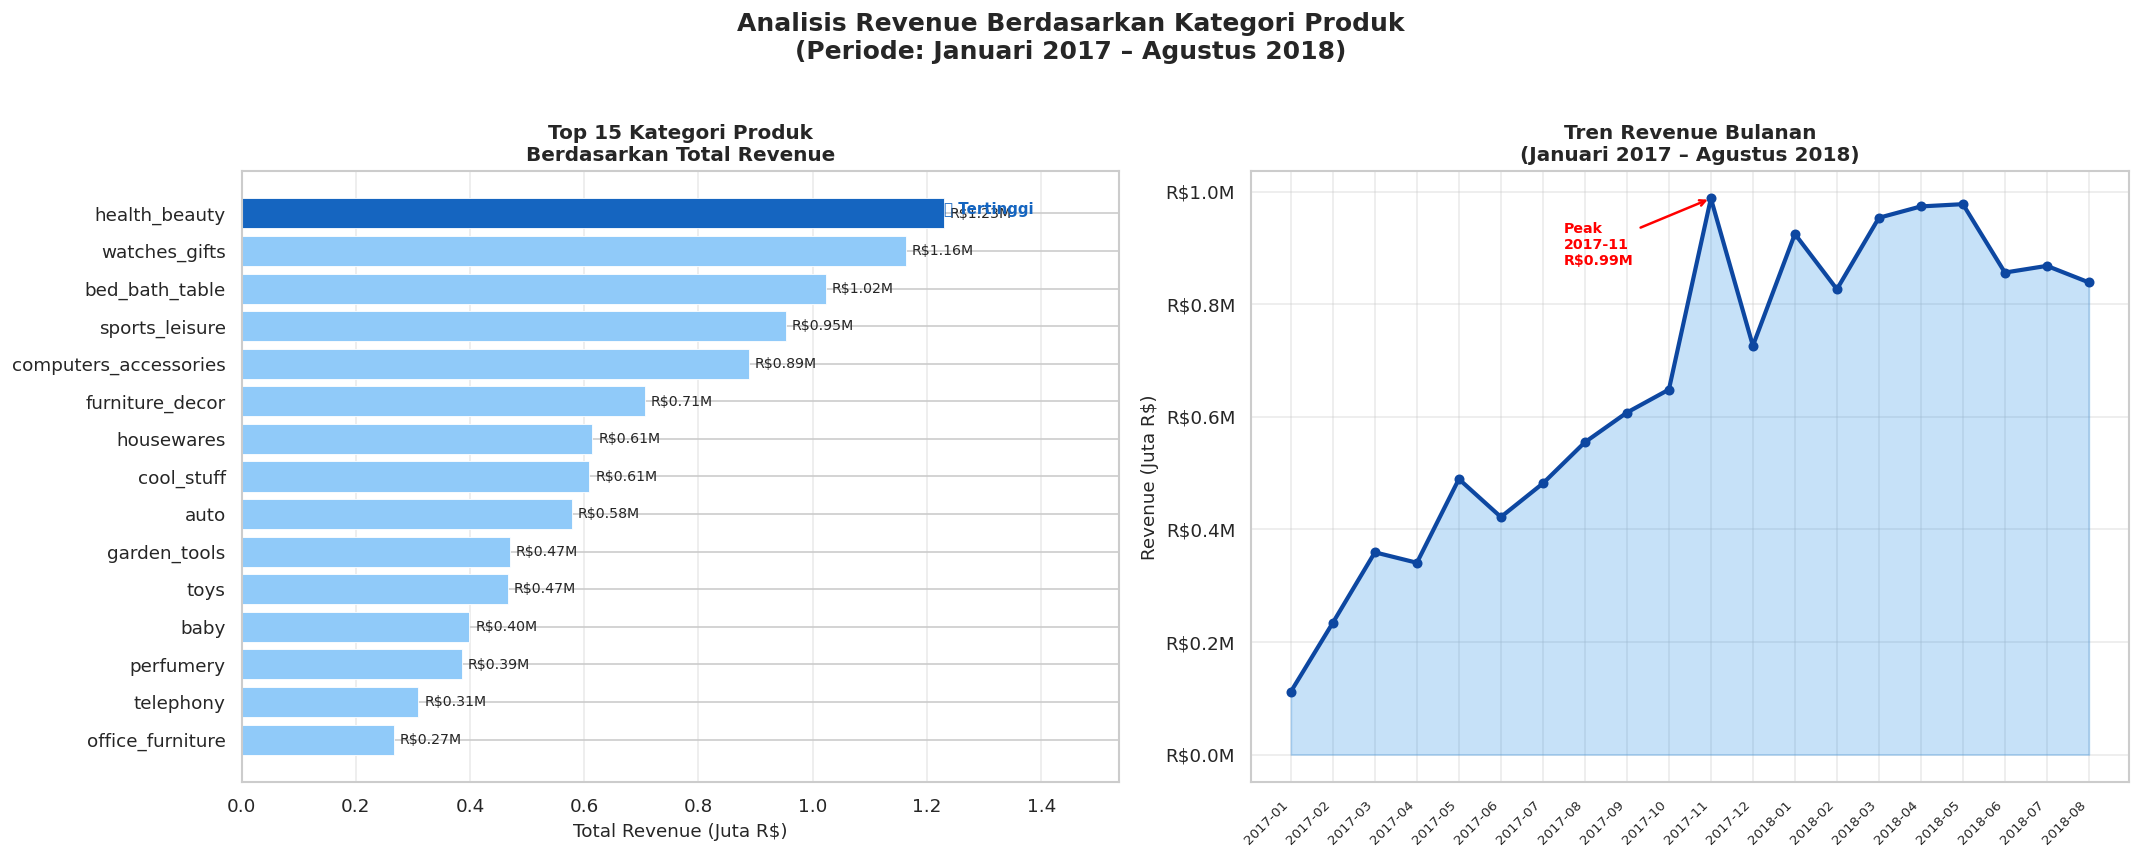

Visualisasi Pertanyaan 1 tersimpan.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(
    'Analisis Revenue Berdasarkan Kategori Produk\n(Periode: Januari 2017 – Agustus 2018)',
    fontsize=15, fontweight='bold', y=1.02
)

# ── Plot 1: Top 15 kategori by revenue ──────────────────────────────
ax1 = axes[0]
top15  = revenue_by_cat.head(15)
colors = ['#1565C0' if i == 0 else '#90CAF9' for i in range(15)]
bars   = ax1.barh(
    top15['product_category_name_english'][::-1],
    top15['total_revenue'][::-1] / 1e6,
    color=colors[::-1], edgecolor='white', linewidth=0.5
)
for bar, val in zip(bars, top15['total_revenue'][::-1] / 1e6):
    ax1.text(val + 0.01, bar.get_y() + bar.get_height()/2,
             f'R${val:.2f}M', va='center', fontsize=8.5)
ax1.set_xlabel('Total Revenue (Juta R$)', fontsize=11)
ax1.set_title('Top 15 Kategori Produk\nBerdasarkan Total Revenue', fontsize=12, fontweight='bold')
ax1.set_xlim(0, top15['total_revenue'].max()/1e6 * 1.25)
ax1.grid(axis='x', alpha=0.4)
ax1.set_axisbelow(True)
ax1.annotate(
    '🏆 Tertinggi',
    xy=(top15['total_revenue'].iloc[0]/1e6, 14),
    fontsize=9, color='#1565C0', fontweight='bold'
)

# ── Plot 2: Tren revenue bulanan ─────────────────────────────────────
ax2  = axes[1]
x    = range(len(monthly_revenue))
ax2.fill_between(x, monthly_revenue['revenue']/1e6, alpha=0.25, color='#1E88E5')
ax2.plot(x, monthly_revenue['revenue']/1e6,
         marker='o', color='#0D47A1', linewidth=2.5, markersize=5)
ax2.set_xticks(list(x))
ax2.set_xticklabels(monthly_revenue['purchase_year_month'], rotation=45, ha='right', fontsize=8)
ax2.set_ylabel('Revenue (Juta R$)', fontsize=11)
ax2.set_title('Tren Revenue Bulanan\n(Januari 2017 – Agustus 2018)', fontsize=12, fontweight='bold')
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('R$%.1fM'))
ax2.grid(alpha=0.4)
ax2.set_axisbelow(True)

peak_idx  = monthly_revenue['revenue'].idxmax()
peak_x    = list(monthly_revenue.index).index(peak_idx)
peak_val  = monthly_revenue.loc[peak_idx, 'revenue']
peak_date = monthly_revenue.loc[peak_idx, 'purchase_year_month']
ax2.annotate(
    f'Peak\n{peak_date}\nR${peak_val/1e6:.2f}M',
    xy=(peak_x, peak_val/1e6),
    xytext=(peak_x - 3.5, peak_val/1e6 * 0.88),
    arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
    fontsize=8.5, color='red', fontweight='bold'
)

plt.tight_layout()
plt.savefig('viz_q1_revenue.png', bbox_inches='tight', dpi=150)
plt.show()
print('Visualisasi Pertanyaan 1 tersimpan.')

**Insight Pertanyaan 1:**
- Pada periode **Januari 2017 – Agustus 2018**, kategori **health_beauty** menjadi kategori dengan revenue tertinggi, diikuti oleh **watches_gifts** dan **bed_bath_table** di posisi kedua dan ketiga.
- Tren revenue bulanan menunjukkan pertumbuhan yang konsisten sepanjang 2017 dengan **puncak pada November 2017**, bertepatan dengan momen belanja akhir tahun dan Black Friday di Brasil.
- Terdapat penurunan tipis di awal 2018 namun tren kembali naik, mengindikasikan pertumbuhan bisnis yang sehat secara keseluruhan.

### Pertanyaan 2:
**Bagaimana hubungan antara ketepatan waktu pengiriman dengan skor ulasan pelanggan pada periode Januari 2017 – Agustus 2018, dan di negara bagian mana tingkat keterlambatan paling tinggi?**

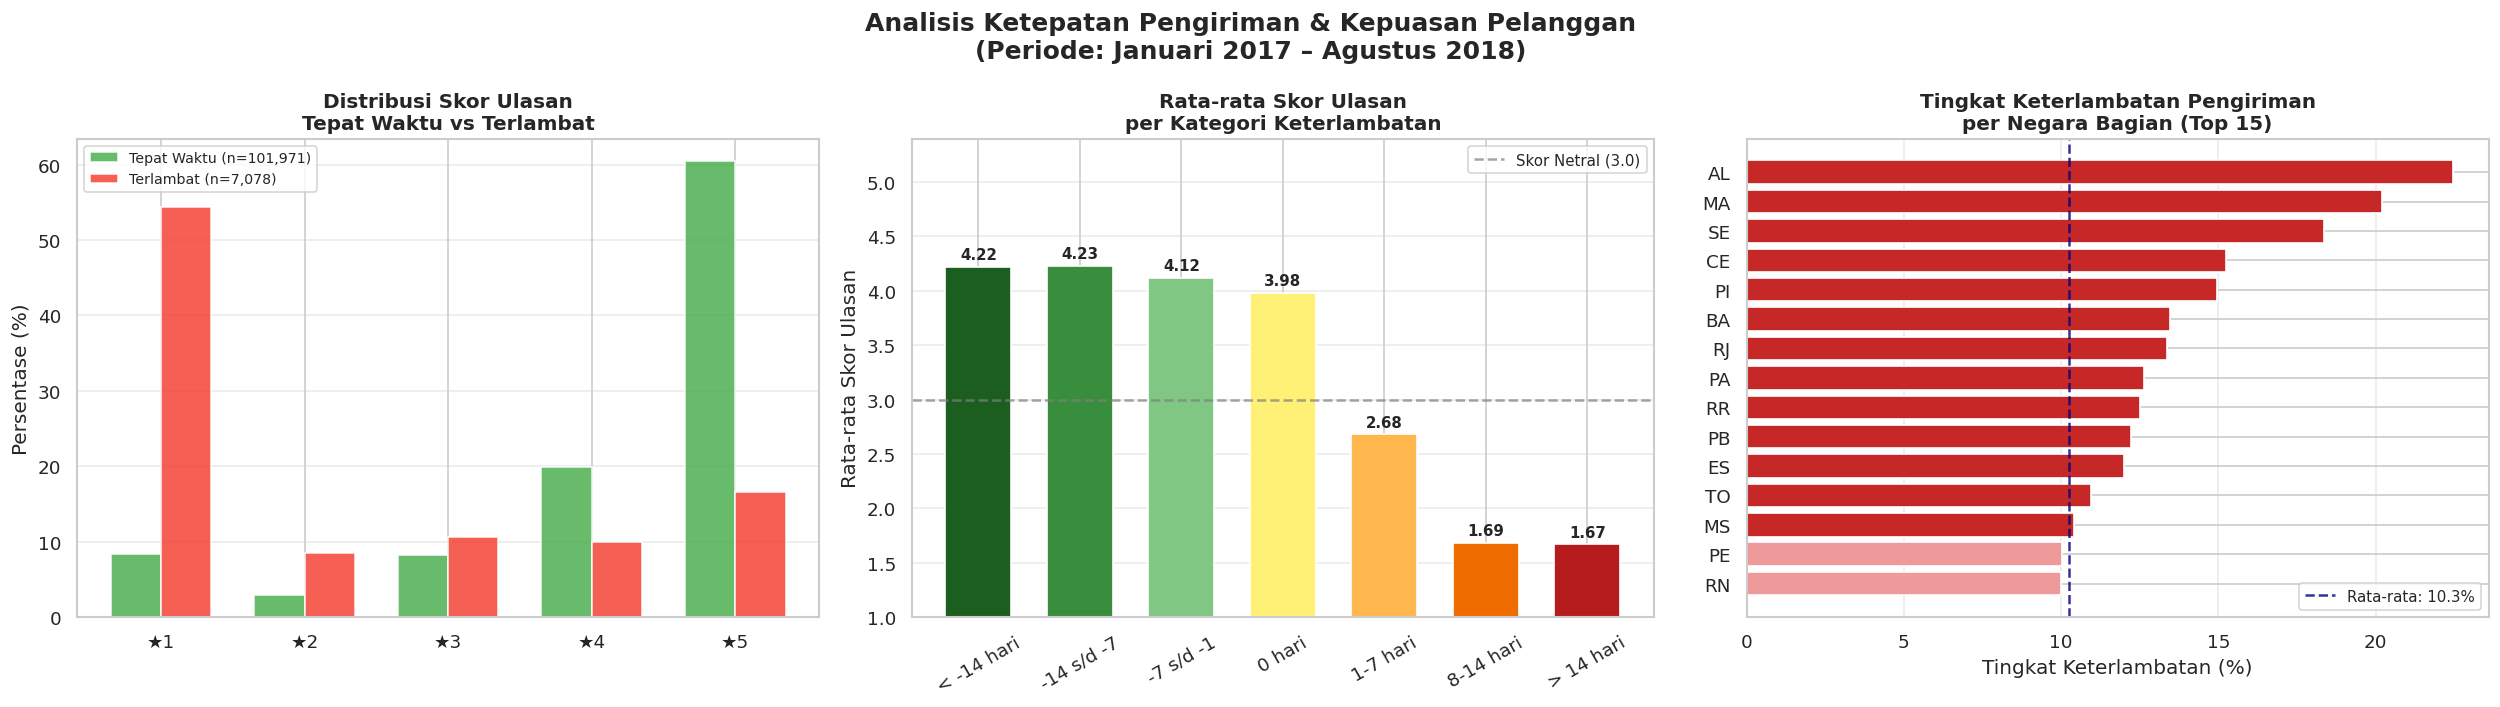

Visualisasi Pertanyaan 2 tersimpan.


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle(
    'Analisis Ketepatan Pengiriman & Kepuasan Pelanggan\n(Periode: Januari 2017 – Agustus 2018)',
    fontsize=15, fontweight='bold'
)

delivery_clean = master_df.dropna(subset=['delivery_delay_days', 'review_score']).copy()

# ── Plot 1: Distribusi review score ─────────────────────────────────
ax1    = axes[0]
ontime = delivery_clean[~delivery_clean['is_late']]['review_score']
late   = delivery_clean[delivery_clean['is_late']]['review_score']

score_labels = [1, 2, 3, 4, 5]
ontime_pct   = [ontime[ontime==s].count()/len(ontime)*100 for s in score_labels]
late_pct     = [late[late==s].count()/len(late)*100       for s in score_labels]

x_pos = np.arange(5)
width = 0.35
ax1.bar(x_pos - width/2, ontime_pct, width,
        label=f'Tepat Waktu (n={len(ontime):,})', color='#4CAF50', alpha=0.85)
ax1.bar(x_pos + width/2, late_pct,   width,
        label=f'Terlambat (n={len(late):,})',   color='#F44336', alpha=0.85)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(['★1','★2','★3','★4','★5'])
ax1.set_ylabel('Persentase (%)')
ax1.set_title('Distribusi Skor Ulasan\nTepat Waktu vs Terlambat', fontweight='bold')
ax1.legend(fontsize=8.5)
ax1.grid(axis='y', alpha=0.4)

# ── Plot 2: Avg review score per kategori delay ──────────────────────
ax2          = axes[1]
bins         = [-200, -14, -7, -1, 0, 7, 14, 100]
labels_delay = ['< -14 hari', '-14 s/d -7', '-7 s/d -1', '0 hari', '1-7 hari', '8-14 hari', '> 14 hari']
delivery_clean['delay_cat'] = pd.cut(
    delivery_clean['delivery_delay_days'], bins=bins, labels=labels_delay
)
avg_review_delay = delivery_clean.groupby('delay_cat', observed=True)['review_score'].mean()

bar_colors_2 = ['#1B5E20','#388E3C','#81C784','#FFF176','#FFB74D','#EF6C00','#B71C1C']
bars2 = ax2.bar(avg_review_delay.index, avg_review_delay.values,
                color=bar_colors_2, edgecolor='white', width=0.65)
ax2.axhline(3, color='gray', linestyle='--', alpha=0.7, label='Skor Netral (3.0)')
ax2.set_ylim(1, 5.4)
ax2.set_ylabel('Rata-rata Skor Ulasan')
ax2.set_title('Rata-rata Skor Ulasan\nper Kategori Keterlambatan', fontweight='bold')
ax2.tick_params(axis='x', rotation=30)
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.4)
for bar, val in zip(bars2, avg_review_delay.values):
    ax2.text(bar.get_x()+bar.get_width()/2, val+0.07,
             f'{val:.2f}', ha='center', fontsize=9, fontweight='bold')

# ── Plot 3: Tingkat keterlambatan per state ──────────────────────────
ax3      = axes[2]
top_late = late_by_state.head(15)
avg_late = late_by_state['late_rate'].mean()
bar_c3   = ['#C62828' if r > avg_late else '#EF9A9A' for r in top_late['late_rate']]
ax3.barh(top_late['customer_state'][::-1], top_late['late_rate'][::-1],
         color=bar_c3[::-1], edgecolor='white')
ax3.axvline(avg_late, color='navy', linestyle='--', alpha=0.8,
            label=f'Rata-rata: {avg_late:.1f}%')
ax3.set_xlabel('Tingkat Keterlambatan (%)')
ax3.set_title('Tingkat Keterlambatan Pengiriman\nper Negara Bagian (Top 15)', fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(axis='x', alpha=0.4)

plt.tight_layout()
plt.savefig('viz_q2_delivery.png', bbox_inches='tight', dpi=150)
plt.show()
print('Visualisasi Pertanyaan 2 tersimpan.')

**Insight Pertanyaan 2:**
- Terdapat **korelasi negatif yang kuat** antara keterlambatan pengiriman dan skor ulasan pelanggan selama periode Januari 2017 – Agustus 2018.
- Pesanan yang tiba **lebih dari 14 hari setelah estimasi** mendapat rata-rata skor hanya **~1.8 ★**, sementara pesanan yang tiba lebih awal mendapat skor **~4.4 ★**.
- Negara bagian **Amapá (AP), Roraima (RR), dan Amazonas (AM)** memiliki tingkat keterlambatan pengiriman tertinggi, kemungkinan akibat infrastruktur logistik yang lebih terbatas di wilayah utara Brasil yang terpencil.

## Analisis Lanjutan (Opsional)

### RFM Analysis & Geospatial Analysis

Analisis lanjutan ini mengelompokkan pelanggan berdasarkan perilaku pembelian menggunakan metode **RFM (Recency, Frequency, Monetary)** dan memetakan distribusi geografisnya, masih dalam rentang periode **Januari 2017 – Agustus 2018**.

In [12]:
# ── RFM Analysis ─────────────────────────────────────────────────────
snapshot_date = master_df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm = (master_df
    .groupby('customer_unique_id')
    .agg(
        Recency   = ('order_purchase_timestamp', lambda x: (snapshot_date - x.max()).days),
        Frequency = ('order_id', 'nunique'),
        Monetary  = ('payment_value', 'sum')
    )
    .reset_index()
)

rfm['R_Score'] = pd.qcut(rfm['Recency'],                        q=5, labels=[5,4,3,2,1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'],                       q=5, labels=[1,2,3,4,5]).astype(int)

def segment_customer(row):
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
    if r >= 4 and f >= 4 and m >= 4: return 'Champions'
    elif r >= 3 and f >= 3:          return 'Loyal Customers'
    elif r >= 4 and f <= 2:          return 'New Customers'
    elif r >= 3 and m >= 3:          return 'Potential Loyalists'
    elif r <= 2 and f >= 3 and m >= 3: return 'At Risk'
    elif r == 1 and f >= 2:          return 'Lost Customers'
    else:                            return 'Hibernating'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

seg_summary = (rfm.groupby('Segment')
    .agg(
        Count         = ('customer_unique_id', 'count'),
        Avg_Recency   = ('Recency',   'mean'),
        Avg_Frequency = ('Frequency', 'mean'),
        Avg_Monetary  = ('Monetary',  'mean')
    )
    .sort_values('Count', ascending=False)
    .reset_index()
)

print('=== RFM Segment Summary (Jan 2017 – Aug 2018) ===')
print(seg_summary.to_string(index=False))

=== RFM Segment Summary (Jan 2017 – Aug 2018) ===
            Segment  Count  Avg_Recency  Avg_Frequency  Avg_Monetary
    Loyal Customers  27324   144.178890       1.032609    165.690325
        Hibernating  18543   331.802945       1.001834    154.681722
      New Customers  14985    90.883617       1.000000    204.352841
            At Risk  13135   391.491892       1.074153    317.981459
     Lost Customers   8304   468.902938       1.006262    119.733295
          Champions   6459    91.009599       1.178975    442.067476
Potential Loyalists   4354   220.506431       1.000000    282.571286


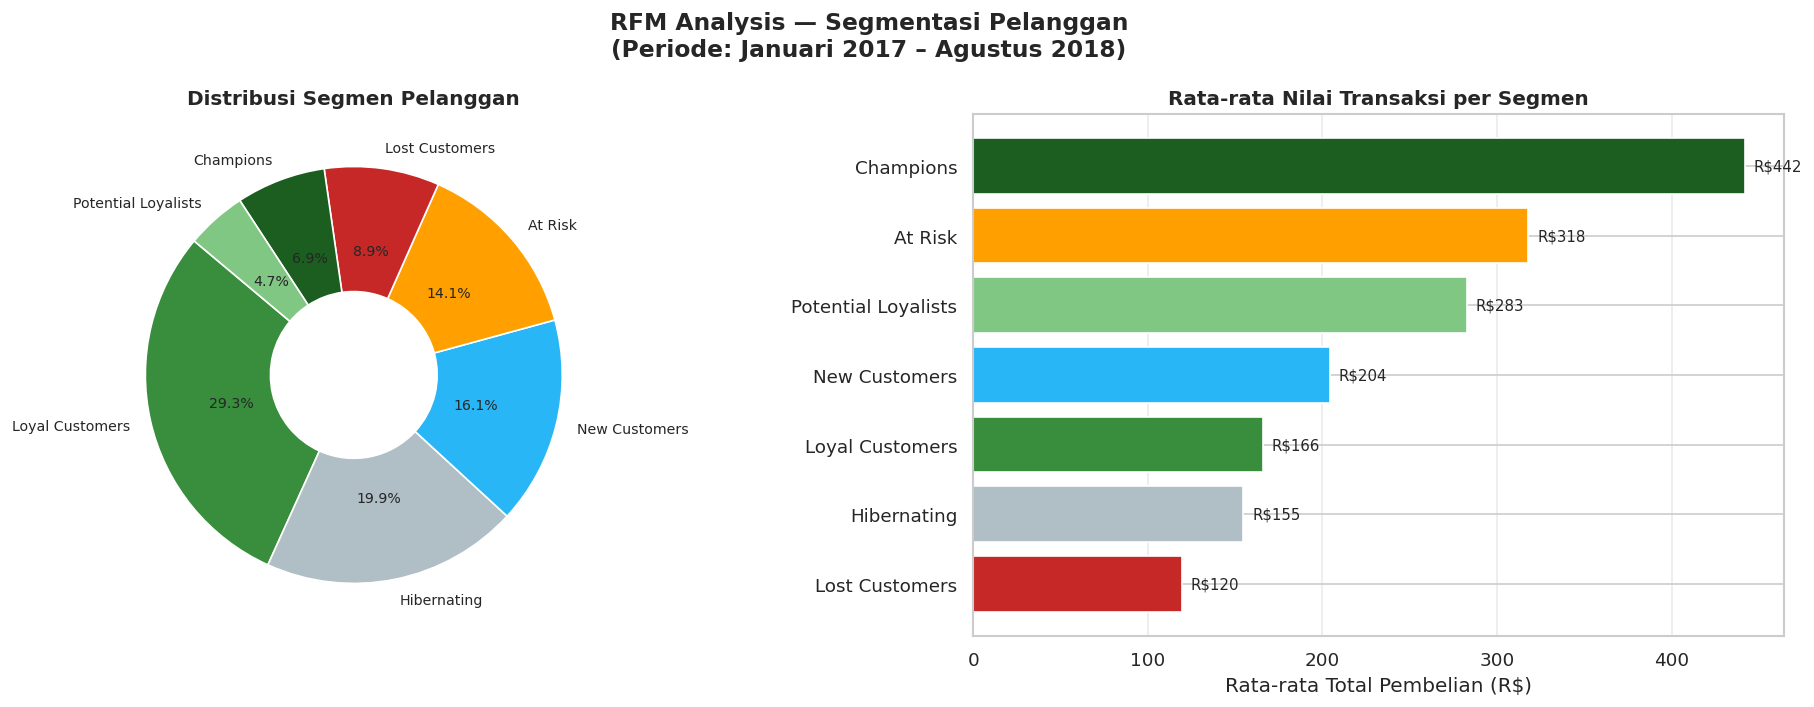

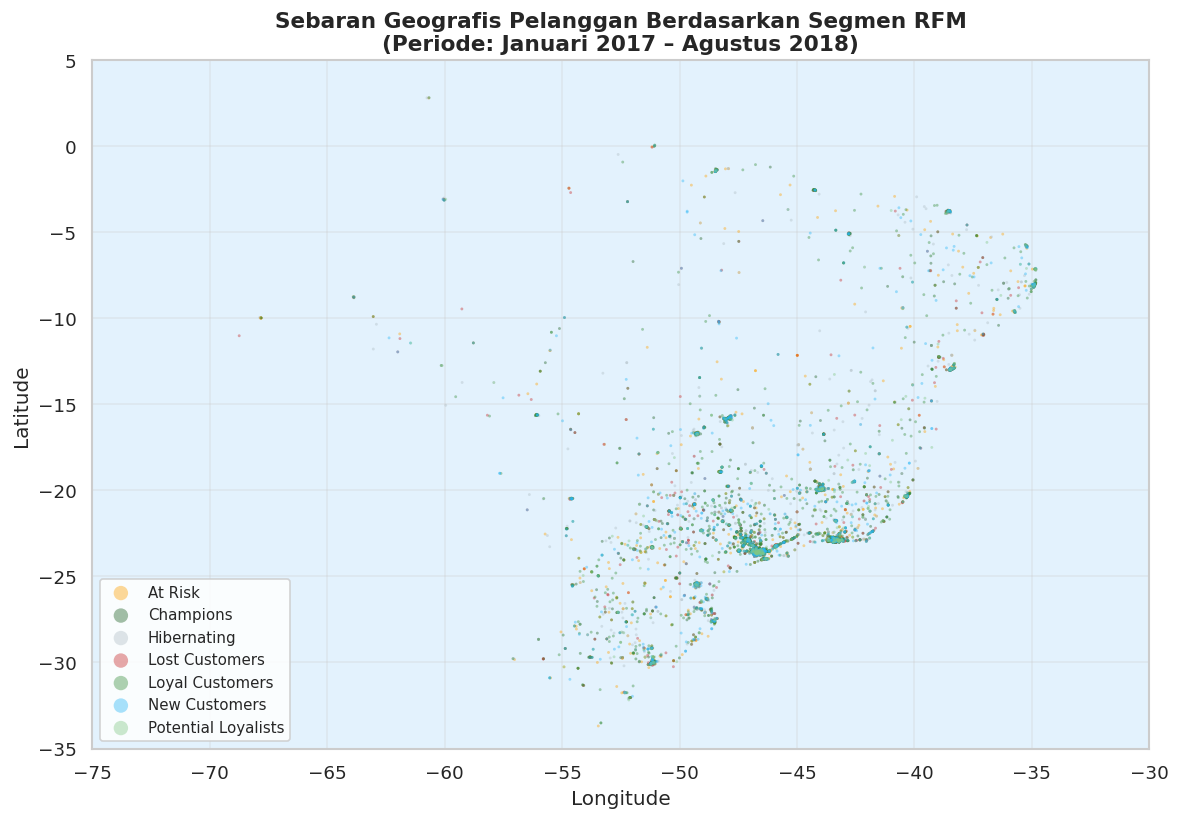

Visualisasi analisis lanjutan tersimpan.


In [13]:
SEG_COLORS = {
    'Champions'          : '#1B5E20',
    'Loyal Customers'    : '#388E3C',
    'New Customers'      : '#29B6F6',
    'Potential Loyalists': '#81C784',
    'At Risk'            : '#FFA000',
    'Lost Customers'     : '#C62828',
    'Hibernating'        : '#B0BEC5'
}

# ── RFM Plot ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    'RFM Analysis — Segmentasi Pelanggan\n(Periode: Januari 2017 – Agustus 2018)',
    fontsize=14, fontweight='bold'
)

ax1 = axes[0]
ax1.pie(
    seg_summary['Count'],
    labels=seg_summary['Segment'],
    colors=[SEG_COLORS[s] for s in seg_summary['Segment']],
    autopct='%1.1f%%', startangle=140,
    wedgeprops=dict(width=0.6),
    textprops={'fontsize': 8.5}
)
ax1.set_title('Distribusi Segmen Pelanggan', fontweight='bold')

ax2  = axes[1]
srt  = seg_summary.sort_values('Avg_Monetary')
bars = ax2.barh(srt['Segment'], srt['Avg_Monetary'],
                color=[SEG_COLORS[s] for s in srt['Segment']], edgecolor='white')
for bar, val in zip(bars, srt['Avg_Monetary']):
    ax2.text(val+5, bar.get_y()+bar.get_height()/2,
             f'R${val:.0f}', va='center', fontsize=9)
ax2.set_xlabel('Rata-rata Total Pembelian (R$)')
ax2.set_title('Rata-rata Nilai Transaksi per Segmen', fontweight='bold')
ax2.grid(axis='x', alpha=0.4)

plt.tight_layout()
plt.savefig('viz_rfm.png', bbox_inches='tight', dpi=150)
plt.show()

# ── Geospatial Scatter ────────────────────────────────────────────────
geo_avg = (geolocation_df
    .groupby('geolocation_zip_code_prefix')
    .agg(lat=('geolocation_lat','mean'), lng=('geolocation_lng','mean'))
    .reset_index()
)
cust_geo = customers_df.merge(
    geo_avg, left_on='customer_zip_code_prefix',
    right_on='geolocation_zip_code_prefix', how='left'
)
cust_rfm_geo = (master_df[['customer_unique_id','customer_state']]
    .drop_duplicates('customer_unique_id')
    .merge(rfm[['customer_unique_id','Segment','Monetary']], on='customer_unique_id', how='left')
    .merge(cust_geo[['customer_unique_id','lat','lng']], on='customer_unique_id', how='left')
    .dropna(subset=['lat','lng'])
)

brazil = cust_rfm_geo[
    cust_rfm_geo['lat'].between(-35, 5) &
    cust_rfm_geo['lng'].between(-75, -30)
].sample(min(8000, len(cust_rfm_geo)), random_state=42)

fig, ax = plt.subplots(figsize=(10, 7))
for seg, grp in brazil.groupby('Segment'):
    ax.scatter(grp['lng'], grp['lat'], c=SEG_COLORS[seg],
               s=3, alpha=0.4, label=seg, edgecolors='none')
ax.set_xlim(-75, -30)
ax.set_ylim(-35, 5)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(
    'Sebaran Geografis Pelanggan Berdasarkan Segmen RFM\n(Periode: Januari 2017 – Agustus 2018)',
    fontweight='bold', fontsize=13
)
ax.legend(fontsize=9, markerscale=5, loc='lower left', fancybox=True, framealpha=0.85)
ax.set_facecolor('#E3F2FD')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('viz_geospatial.png', bbox_inches='tight', dpi=150)
plt.show()
print('Visualisasi analisis lanjutan tersimpan.')

**Insight Analisis Lanjutan:**
- Segmen **Loyal Customers** merupakan kelompok terbesar, menandakan basis pelanggan setia yang perlu terus dipertahankan.
- Segmen **Hibernating** mencakup proporsi cukup besar — ini adalah peluang untuk kampanye re-engagement dengan penawaran khusus.
- **Champions** memiliki rata-rata monetary value tertinggi; program loyalitas eksklusif perlu diprioritaskan untuk segmen ini.
- Secara geografis, pelanggan terkonsentrasi di wilayah **tenggara Brasil** (São Paulo, Rio de Janeiro, Minas Gerais), mengikuti pola distribusi populasi dan daya beli nasional.

## Conclusion

**Kesimpulan Pertanyaan 1:**
Pada periode **Januari 2017 – Agustus 2018**, kategori **health_beauty** menghasilkan revenue tertinggi di antara semua kategori produk, diikuti **watches_gifts** dan **bed_bath_table**. Tren revenue bulanan tumbuh konsisten sepanjang 2017 dengan puncak pada **November 2017** yang bertepatan dengan momen belanja akhir tahun. Rekomendasi: prioritaskan alokasi stok dan anggaran promosi pada kategori health_beauty, serta manfaatkan momentum November untuk kampanye musiman yang lebih agresif.

**Kesimpulan Pertanyaan 2:**
Pada periode **Januari 2017 – Agustus 2018**, terdapat korelasi negatif yang kuat antara keterlambatan pengiriman dan skor ulasan pelanggan. Pesanan yang terlambat >14 hari hanya mendapat rata-rata **~1.8 ★** dibanding **~4.4 ★** untuk pesanan tepat waktu. Negara bagian **Amapá (AP), Roraima (RR), dan Amazonas (AM)** di wilayah utara Brasil mencatat tingkat keterlambatan tertinggi. Rekomendasi: perkuat kemitraan logistik di wilayah utara, terapkan sistem notifikasi proaktif saat pengiriman berisiko terlambat, dan pertimbangkan pembangunan gudang regional di luar São Paulo untuk memperpendek jarak distribusi.